In [1]:

import pandas as pd
import numpy as np
from scipy.spatial.distance import mahalanobis
from scipy.spatial.distance import euclidean
from sklearn.metrics import confusion_matrix

test_in = pd.read_csv(r"data/test_in - Copy.csv",header=None)
test_out = pd.read_csv(r"data/test_out - Copy.csv",header=None)
test_out = test_out.rename(columns={0:"label"})
train_in = pd.read_csv(r"data/train_in - Copy.csv",header=None)
train_out = pd.read_csv(r"data/train_out - Copy.csv",header=None)
train_out = train_out.rename(columns={0:"label"})
train_set = pd.concat([train_in,train_out],axis=1)
test_set = pd.concat([test_in,test_out],axis=1)


In [2]:
centroids = train_set.groupby("label").mean()
results = []

x = train_in
y = train_set["label"]
c = centroids

matching_centroids = c.loc[y].set_axis(x.index)
train_in_mahalanobis = x - matching_centroids

inverse_of_cov = np.linalg.inv(train_in_mahalanobis.cov())

for _, row in test_set.iterrows():
    predicted_mahalanobis_label = None
    predicted_euclidean_label = None
    smallest_mahalanobis_distance = float("inf")
    smallest_euclidean_distance = float("inf")

    for _, cent in centroids.iterrows():
        dist_mahalanobis = mahalanobis(row.iloc[:-1], cent, inverse_of_cov)
        dist_euclidean = euclidean(row.iloc[:-1], cent)
        label = cent.name

        if dist_mahalanobis < smallest_mahalanobis_distance:
            smallest_mahalanobis_distance = dist_mahalanobis
            predicted_mahalanobis_label = label
        if dist_euclidean < smallest_euclidean_distance:
            smallest_euclidean_distance = dist_euclidean
            predicted_euclidean_label = label

    results.append({"prediction_mahalanobis": predicted_mahalanobis_label, "distance_mahalanobis": smallest_mahalanobis_distance,  "prediction_euclidean": predicted_euclidean_label, "distance_euclidean": smallest_euclidean_distance})

prediction_and_distances = pd.DataFrame(results)
test_set = pd.concat([test_set,prediction_and_distances],axis=1)

total_count_test = len(test_set)

accuracy_euclidean = (test_set["label"] == test_set["prediction_euclidean"]).mean()
accuracy_mahalanobis = (test_set["label"] == test_set["prediction_mahalanobis"]).mean()
print("Euclidean accuracy:\t",accuracy_euclidean,"\nMahalanobis accuracy:",accuracy_mahalanobis)



Euclidean accuracy:	 0.804 
Mahalanobis accuracy: 0.88


In [3]:
from scipy.spatial.distance import cdist,pdist
from itertools import combinations

labels = combinations(range(10),2)
labels = pd.DataFrame(labels)
labels = labels.rename(columns={0:"label1",1:"label2"})

centroids_distances_euclidean = pd.DataFrame(pdist(centroids,metric="euclidean"))
centroids_distances_euclidean[["label1","label2"]] = labels[["label1","label2"]]
centroids_distances_euclidean = centroids_distances_euclidean.rename(columns={0:"dist"})

centroids_distances_mahalanobis = pd.DataFrame(pdist(centroids,metric="mahalanobis",VI=inverse_of_cov))
centroids_distances_mahalanobis[["label1","label2"]] = labels[["label1","label2"]]
centroids_distances_mahalanobis = centroids_distances_mahalanobis.rename(columns={0:"dist"})


centroids_distances_mahalanobis.nsmallest(5,"dist")

,dist,label1,label2
43,5.709611,7,9
34,6.114444,4,9
33,7.025403,4,8
22,7.037856,2,8
37,7.093449,5,8


In [4]:
centroids_distances_euclidean.nsmallest(5,"dist")


,dist,label1,label2
43,5.426474,7,9
34,6.010408,4,9
25,6.118750,3,5
44,6.401166,8,9
35,6.698692,5,6


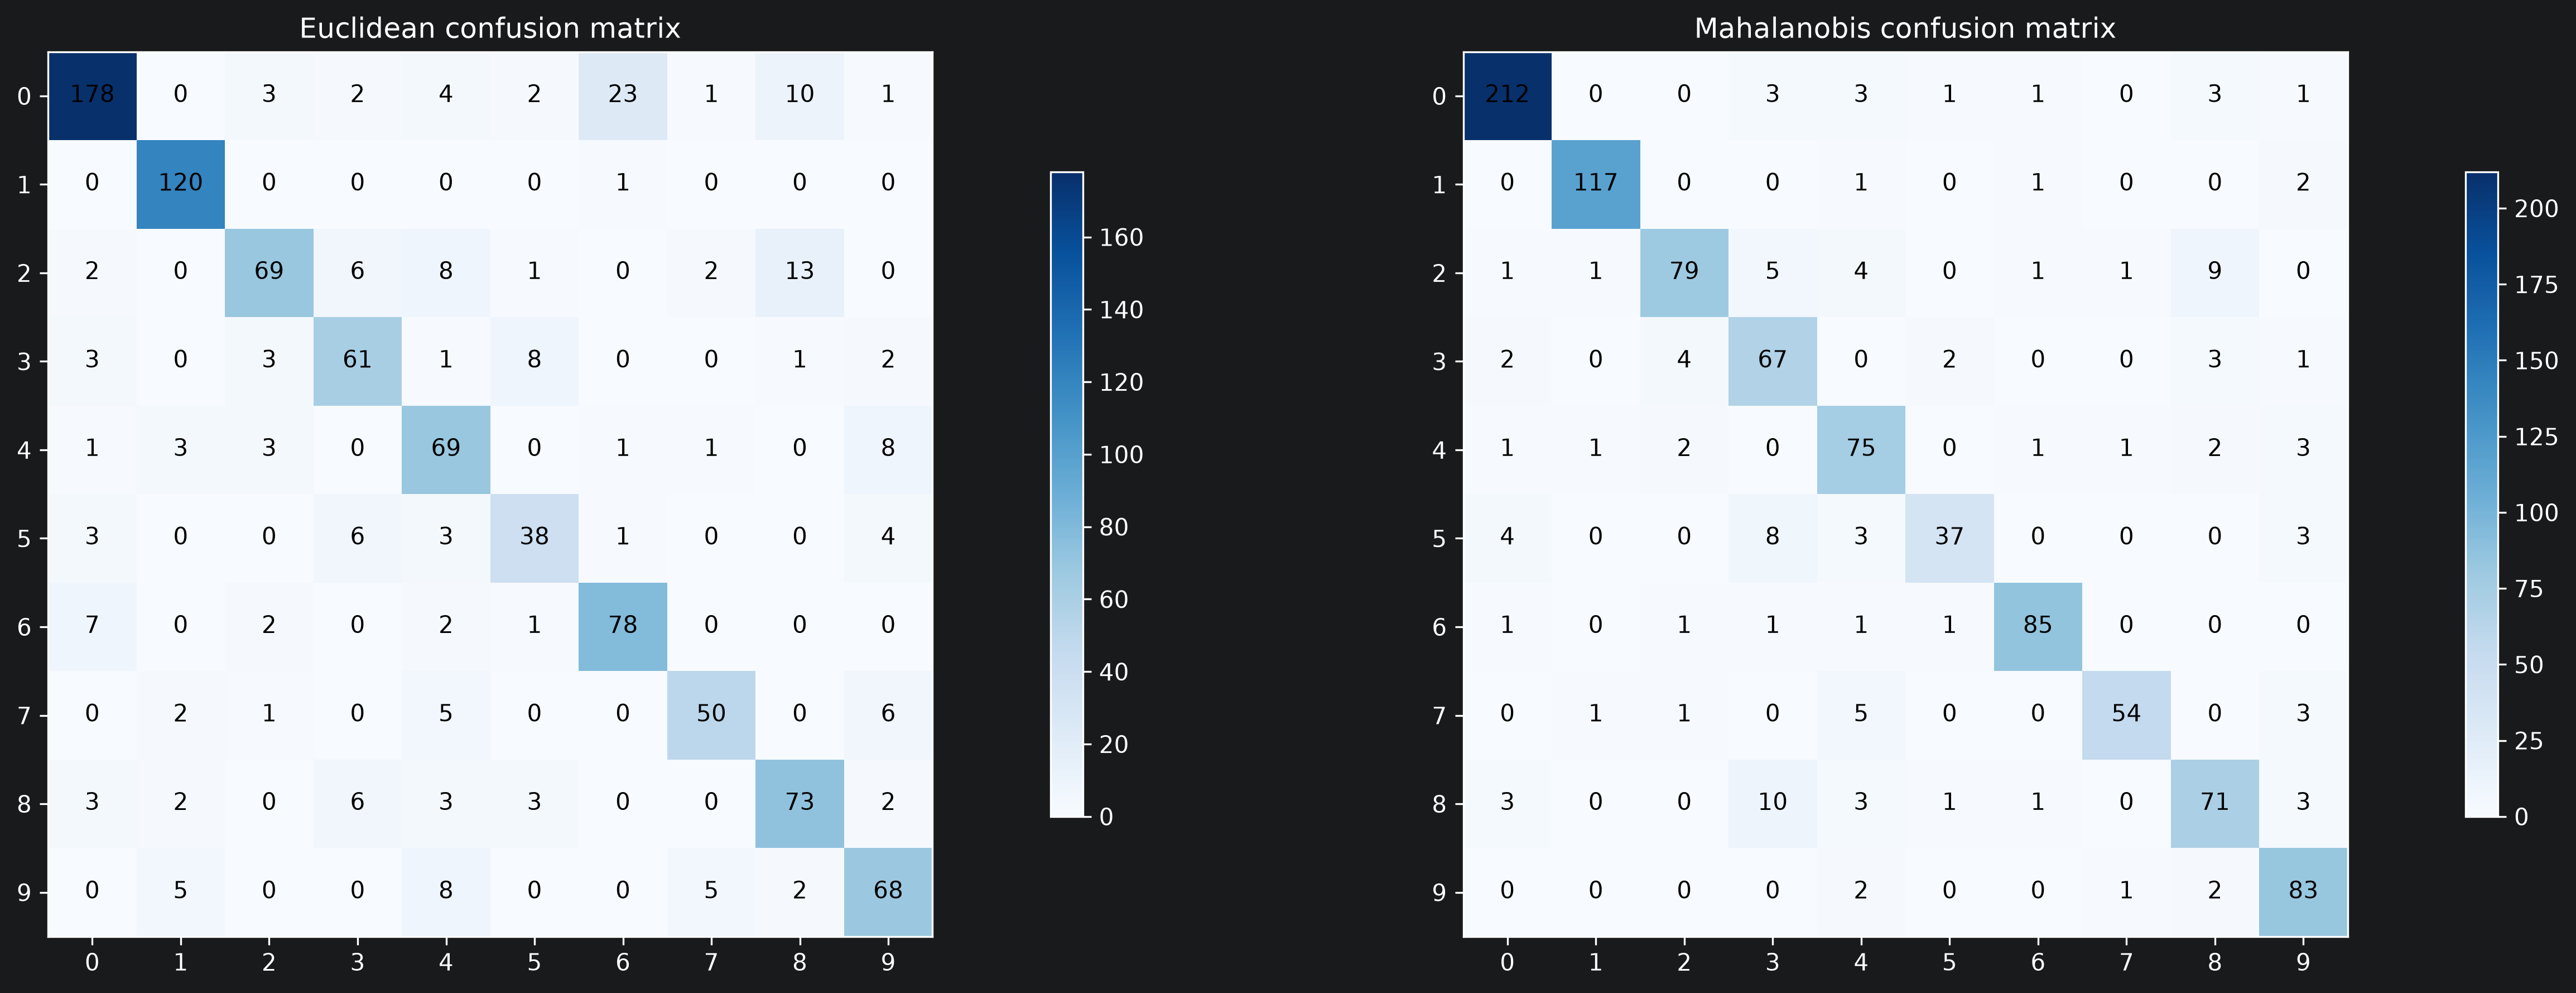

In [35]:
confusion_matrix_euclid = pd.crosstab(test_set["label"], test_set["prediction_euclidean"])
confusion_matrix_mahala = pd.crosstab(test_set["label"], test_set["prediction_mahalanobis"])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2,figsize=(20,10))

picture_euclid = axes[0].imshow(confusion_matrix_euclid,cmap=plt.cm.Blues)
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))
for x in range(10):
    for y in range(10):
        axes[0].text(x,y,confusion_matrix_euclid.iloc[y,x],color="black",ha="center",va="center")
fig.colorbar(picture_euclid, ax=axes[0],pad=0.1,shrink=0.5)
axes[0].set_title("Euclidean confusion matrix")

picture_mahala = axes[1].imshow(confusion_matrix_mahala,cmap=plt.cm.Blues)
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
for x in range(10):
    for y in range(10):
        axes[1].text(x,y,confusion_matrix_mahala.iloc[y,x],color="black",ha="center",va="center")
fig.colorbar(picture_mahala, ax=axes[1],pad= 0.1,shrink=0.5)
axes[1].set_title("Mahalanobis confusion matrix")

fig.subplots_adjust(wspace=0.2)
fig.set_dpi(300)
plt.show()